# Análisis de Agrupamiento (Clustering K-Means)
## Segmentación de Ecosistemas Marinos por Condiciones Ambientales

---

## ¿Qué es K-Means Clustering?

El **algoritmo K-Means** divide un conjunto de observaciones en **k grupos (clusters)** de forma que las observaciones dentro de cada grupo sean lo más similares posible entre sí, minimizando la **suma de distancias cuadradas** (SSE) entre cada punto y el centroide de su cluster.

**Función objetivo a minimizar:**
$$SSE = \sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$$

Donde $\mu_j$ es el centroide del cluster $j$.

### Algoritmo Iterativo

1. **Inicialización**: Seleccionar k centroides aleatorios (o con K-Means++)
2. **Asignación**: Cada punto se asigna al centroide más cercano
3. **Actualización**: Los centroides se recalculan como la media de sus puntos asignados
4. **Convergencia**: Repetir pasos 2-3 hasta que no cambien las asignaciones

---

## Supuestos del Método

| Supuesto | Descripción |
|----------|-------------|
| **Escala uniforme** | Variables deben estandarizarse; K-Means usa distancias euclidianas |
| **Clusters esféricos** | K-Means asume clusters aproximadamente circulares y del mismo tamaño |
| **k conocido** | El número de grupos debe especificarse a priori (usar Elbow Method o Silhouette) |
| **Sin outliers extremos** | Los outliers distorsionan la posición de los centroides |

---

## Métricas de Validación de Clusters

### Coeficiente de Silhouette
Para cada observación $i$:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Donde:
- $a(i)$ = distancia media intra-cluster (cohesión)
- $b(i)$ = distancia media al cluster vecino más cercano (separación)
- $s(i) \in [-1, 1]$: valores cercanos a +1 indican clusters bien definidos

### Método del Codo (Elbow Method)
Graficar SSE vs. k y buscar el punto donde la reducción de SSE se aplana — ese es el k óptimo.

---

## Objetivos de Aprendizaje

- Aplicar K-Means para identificar tipos de hábitat marino basados en condiciones ambientales
- Determinar el número óptimo de clusters con método del codo y puntuación de silhouette
- Interpretar perfiles de cluster: qué combinación de variables define cada grupo
- Visualizar clusters en espacio 2D y evaluar su separación

---

## Aplicaciones Marino-Costeras

- Identificar tipos de hábitat basados en temperatura, salinidad, oxígeno y profundidad
- Clasificar zonas de pesca por productividad oceanográfica
- Agrupar estaciones de monitoreo con patrones de calidad de agua similares
- Segmentar comunidades bentónicas por características del sustrato

---

## Duración Estimada
60-90 minutos


## Marco Comparativo: K-Means vs Otros Métodos de Clustering

### ¿Por qué K-Means para Datos Marinos?

| Método | Ventajas | Limitaciones | Mejor para |
|--------|----------|--------------|------------|
| **K-Means** | Rápido, escalable, intuitivo | Asume clusters esféricos; requiere k a priori | Datos continuos, clusters compactos |
| **DBSCAN** | Detecta clusters de forma arbitraria, identifica outliers | Sensible a parámetros epsilon y minPts | Datos con ruido, formas irregulares |
| **Clustering Jerárquico** | No requiere k a priori, genera dendrograma | Computacionalmente costoso para n grande | Datasets pequeños, exploración inicial |
| **Gaussian Mixture Models** | Clusters elípticos, asigna probabilidades | Más complejo, requiere normalidad | Clusters solapados |

### Distancia Euclidiana en K-Means

K-Means usa distancia euclidiana para medir similitud:
$$d(x, y) = \sqrt{\sum_{i=1}^{p}(x_i - y_i)^2}$$

**Esto implica que:**
- Variables con mayor varianza dominan la distancia → **siempre estandarizar**
- Variables categóricas requieren codificación o métodos alternativos (K-Modes)

### Verificación de Calidad del Clustering

| Métrica | Interpretación | Umbral orientativo |
|---------|----------------|-------------------|
| **Silhouette Score** | Separación y cohesión de clusters | > 0.5 = bueno, > 0.7 = excelente |
| **SSE (Inertia)** | Dispersión intra-cluster total | Buscar codo en Elbow plot |
| **Calinski-Harabasz** | Ratio varianza entre/dentro clusters | Mayor es mejor |
| **Davies-Bouldin** | Similitud media entre clusters | Menor es mejor |

### Estabilidad del Resultado

K-Means puede converger a óptimos locales según la inicialización. Se recomienda:
- Ejecutar con `n_init=10` (o más) para probar múltiples inicializaciones
- Usar `init='k-means++'` que selecciona centroides iniciales dispersos
- Verificar que los resultados sean consistentes entre ejecuciones


Case Use: Classification of Marine Environments Based on Biotic and Abiotic Factors
Problem Description:
Marine scientists are interested in classifying different marine environments based on a combination of biotic and abiotic factors. This classification will help in understanding habitat characteristics and can guide conservation efforts more effectively.

Statistical Technique:
Cluster Analysis will be used to group marine environments into distinct clusters based on similarities in their biotic and abiotic characteristics.

Hypothesis:
The hypothesis is that marine environments can be effectively grouped into distinct ecological zones based on key biotic and abiotic parameters, and these zones will show distinct patterns that are significant for ecological studies and conservation planning.

Simulation Setup:
For this simulation, we'll generate synthetic data for several biotic and abiotic factors across different sample locations in a marine environment:

Water Temperature (degrees Celsius)
Salinity (PSU)
pH Levels
Phytoplankton Density (cells per liter)
Fish Population Density (fish per square kilometer)
We assume data is collected from 150 different locations.

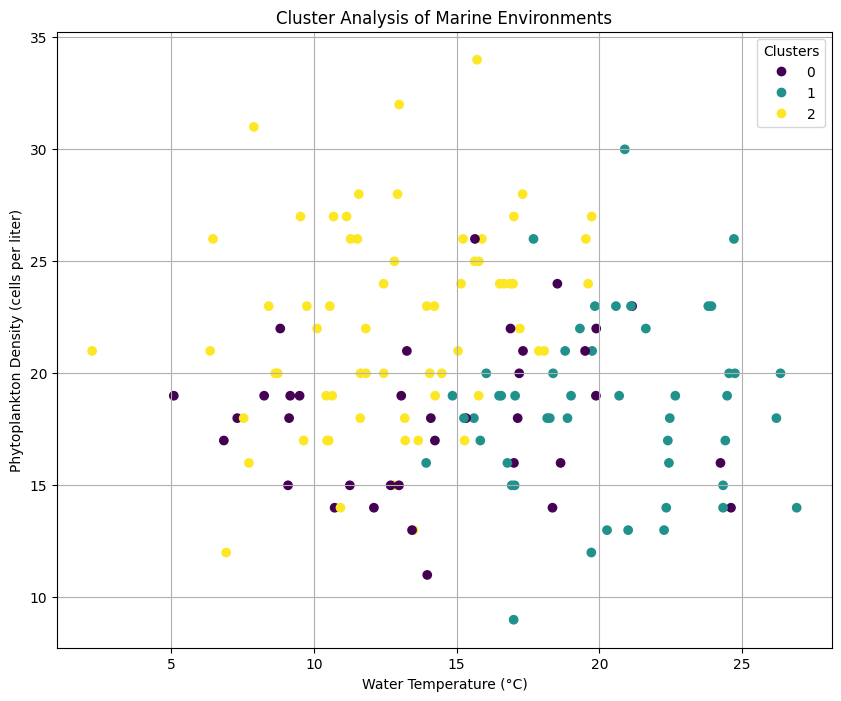

Cluster Centers:
   Temperature   Salinity        pH  Phytoplankton Density  \
0    14.347156  31.360373  7.081333              18.000000   
1    20.344552  36.690204  7.368521              18.510204   
2    12.779339  34.930203  7.668005              22.200000   

   Fish Population Density  
0                45.722222  
1                51.061224  
2                52.369231  


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Generate synthetic data
np.random.seed(0)
data_size = 150

# Biotic and abiotic factors
temperature = np.random.normal(15, 5, data_size)   # Average temperature with variation
salinity = np.random.normal(35, 5, data_size)      # Salinity with some variation
pH = np.random.normal(7.5, 0.5, data_size)         # pH levels
phytoplankton = np.random.poisson(20, data_size)   # Phytoplankton density
fish_density = np.random.poisson(50, data_size)    # Fish population density

data = pd.DataFrame({
    'Temperature': temperature,
    'Salinity': salinity,
    'pH': pH,
    'Phytoplankton Density': phytoplankton,
    'Fish Population Density': fish_density
})

# Standardizing the data
scaler = StandardScaler()
    # Standardize features to zero mean and unit variance
data_scaled = scaler.fit_transform(data)
    # Fit scaler and transform data in one step

# Applying K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(data_scaled)
data['Cluster'] = clusters

# Visualizing the clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(data['Temperature'], data['Phytoplankton Density'], c = data['Cluster'], cmap='viridis')
plt.title('Cluster Analysis of Marine Environments')
plt.xlabel('Water Temperature (°C)')
plt.ylabel('Phytoplankton Density (cells per liter)')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.grid(True)
plt.show()

# Analyzing the cluster centers
print("Cluster Centers:")
print(pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns = data.columns[:-1]))


Silhouette Coefficient: 0.13110210277015238


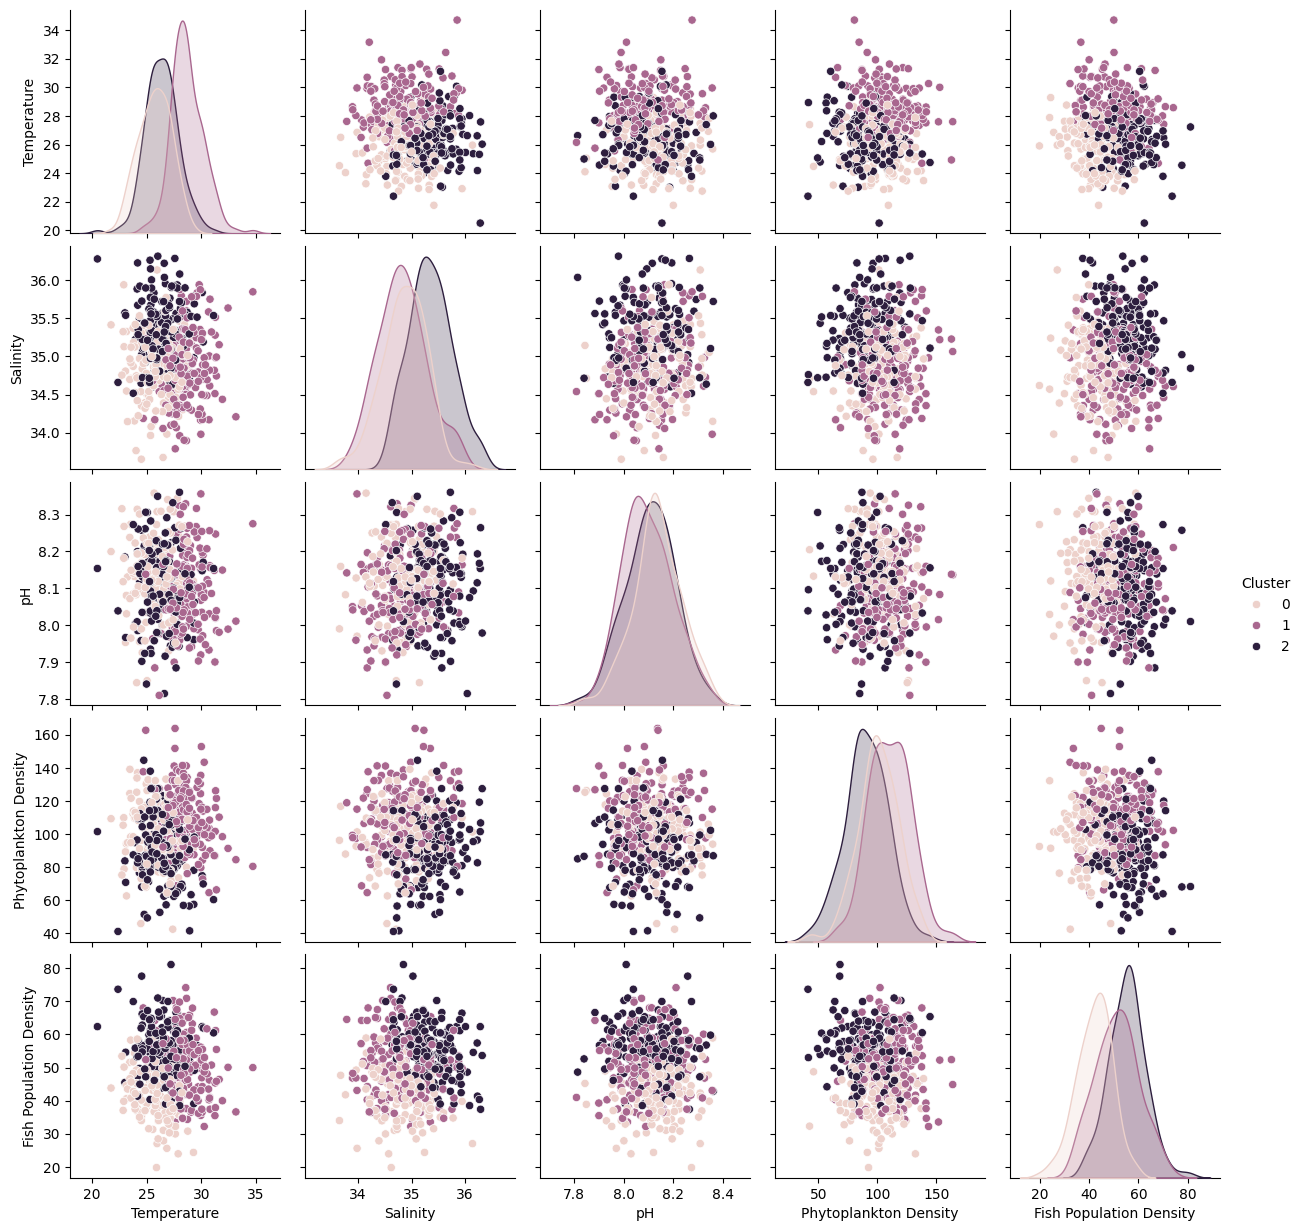

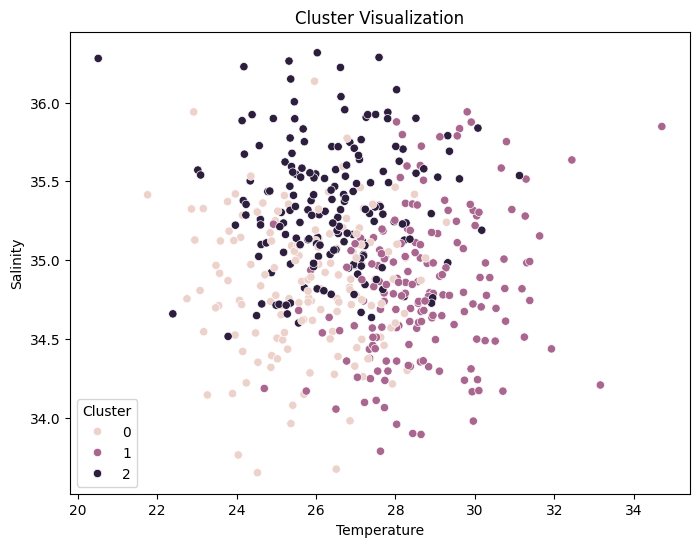

Cluster Centers:
 [[-0.64137415 -0.31936552  0.2311199  -0.00752977 -0.81869487]
 [ 0.86326662 -0.38481015 -0.16194256  0.50337403  0.14764717]
 [-0.32344632  0.68219272 -0.03781515 -0.51434314  0.574901  ]]


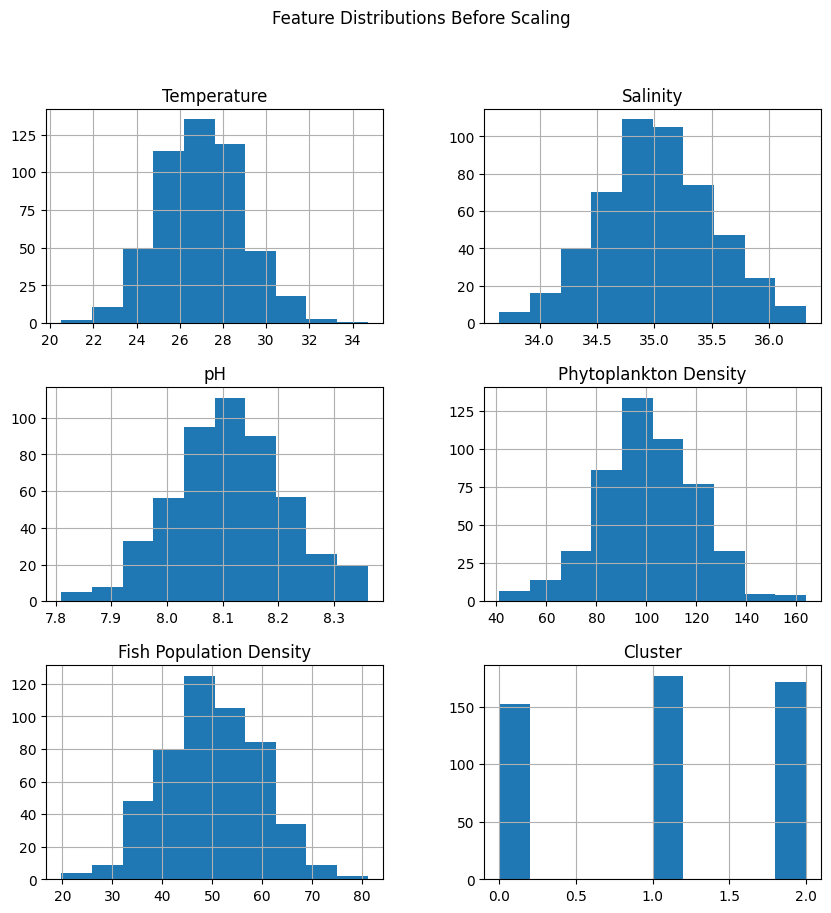

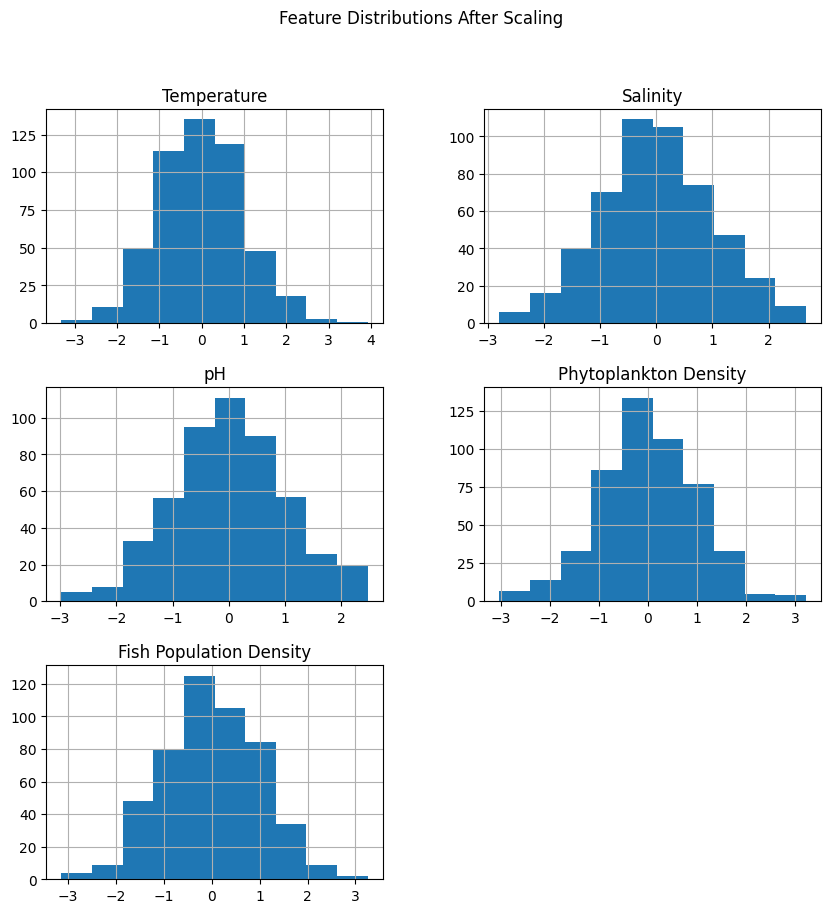

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

# Generate synthetic data
np.random.seed(42)
data_size = 500  # Increase sample size for better results

# Environmental factors
temperature = np.random.normal(27, 2, data_size)  # Average temp 27°C with some variation
salinity = np.random.normal(35, 0.5, data_size) # Average salinity with minor fluctuation
pH = np.random.normal(8.1, 0.1, data_size) # Slightly basic water
phytoplankton = np.random.normal(100, 20, data_size) # Average phytoplankton density
fish_density = np.random.normal(50, 10, data_size) # Average fish population density

# Create dataframe
data = pd.DataFrame({
    'Temperature': temperature,
    'Salinity': salinity,
    'pH': pH,
    'Phytoplankton Density': phytoplankton,
    'Fish Population Density': fish_density
})

# Standardizing the data
scaler = StandardScaler()
    # Standardize features to zero mean and unit variance
data_scaled = scaler.fit_transform(data)
    # Fit scaler and transform data in one step

# Applying K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(data_scaled)
data['Cluster'] = clusters

# Silhouette Analysis
silhouette_coeff = silhouette_score(data_scaled, clusters)
print("Silhouette Coefficient:", silhouette_coeff)

# Pairplot for feature exploration
sns.pairplot(data, hue='Cluster')
plt.show()

# Visualizing the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Temperature', y='Salinity', hue='Cluster', data = data)
plt.title("Cluster Visualization")
plt.show()

# Analyze cluster centers
cluster_centers = kmeans.cluster_centers_
print("Cluster Centers:\n", cluster_centers)

# Distribution plots for each feature pre and post scaling (optional)
data.hist(figsize=(10, 10))
plt.suptitle("Feature Distributions Before Scaling")
plt.show()

data_scaled_df = pd.DataFrame(data_scaled, columns = data.columns[:-1])
data_scaled_df.hist(figsize=(10, 10))
plt.suptitle("Feature Distributions After Scaling")
plt.show()

# Silhouette Score Interpretation Guide:
#
# The silhouette score ranges from -1 to 1:
# - Score close to 1: Point is well matched to its cluster
# - Score close to 0: Point is on the border between clusters
# - Score close to -1: Point may be assigned to wrong cluster
#
# Overall silhouette score interpretation:
# - 0.71-1.00: Strong clustering structure (excellent)
# - 0.51-0.70: Reasonable clustering structure (good)
# - 0.26-0.50: Weak clustering structure (fair, reconsider k)
# - -0.01-0.25: Very weak/no substantial structure (poor)
# - Negative values: Cluster assignment is questionable
#
# Use silhouette scores to:
# 1. Validate the number of clusters (k)
# 2. Identify outliers or misclassified points
# 3. Compare different clustering algorithms
# 4. Assess overall clustering quality

# To visualize silhouette scores for each point:
# from sklearn.metrics import silhouette_samples
# import matplotlib.pyplot as plt
#
# silhouette_vals = silhouette_samples(X_scaled, cluster_labels)
#
# y_lower = 10
# for i in range(n_clusters):
#     cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
#     cluster_silhouette_vals.sort()
#
#     size_cluster_i = cluster_silhouette_vals.shape[0]
#     y_upper = y_lower + size_cluster_i
#
#     plt.fill_betweenx(np.arange(y_lower, y_upper),
#                       0, cluster_silhouette_vals,
#                       alpha=0.7, label=f'Cluster {i}')
#     y_lower = y_upper + 10


# Ejercicios para el Estudiante

## Ejercicio 1: K-means en Datos de Hábitats Marinos
Utiliza datos ambientales de múltiples sitios marinos (temperatura, profundidad, salinidad, nutrientes).
- Estandariza los datos
- Determina el número óptimo de clusters usando método del codo y silhueta
- Aplica K-means y visualiza los resultados
- ¿Qué características ambientales definen cada cluster?

## Ejercicio 2: Clustering Jerárquico
Con los mismos datos del Ejercicio 1:
- Realiza clustering jerárquico aglomerativo
- Crea un dendrograma
- Compara los resultados con K-means
- ¿Cuál método produce agrupaciones más interpretables?

## Ejercicio 3: Validación de Clusters
Para tu mejor modelo de clustering:
- Calcula puntuación de silhueta para cada punto
- Identifica puntos mal clasificados (puntuación negativa)
- Calcula índice de Davies-Bouldin
- Interpreta la calidad general del clustering
- ¿Cómo podrías mejorar la validez de los clusters?